In [1]:
# CRISPR CAR-T Project — PCA & Functional Module Summary

# This notebook summarizes the main analyses for the CRISPR CAR-T project:

# 1. Load processed expression & metadata.
# 2. Run PCA on selected features.
# 3. Interpret PCs using effector and regulatory gene modules.
# 4. Assign cells to quadrants based on PC5/PC6 (effector vs regulatory axes).
# 5. Visualize key results and save figures + tables.

#Your notebook order should look like this:
#1️⃣ Cell 0 — Project Init
#2️⃣ Load expression + metadata
#3️⃣ Run PCA
#4️⃣ Save PCA results
#5️⃣ Build meta_pca
#6️⃣ Define plotting helpers
#7️⃣ Biological PC1/PC2 annotated figure
#8️⃣ Optional: Full pipeline wrapper at bottom
#This makes the notebook deterministic, restart-safe, and clean.

# Notebook goal: provide a clean, reproducible narrative from raw matrices → interpretable biology.

In [2]:
from pathlib import Path
import sys, os

# Adjust if your path differs
PROJECT_ROOT = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis").resolve()

# 1) Make Jupyter "stand" in the project root
os.chdir(PROJECT_ROOT)
print("CWD:", Path.cwd())

# 2) Make Python able to import your package
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Sanity checks
print("analysis_utils exists:", (PROJECT_ROOT / "analysis_utils").exists())
print("analysis_utils/__init__.py exists:", (PROJECT_ROOT / "analysis_utils" / "__init__.py").exists())


CWD: /Users/acastano/Desktop/crispr_carT_AI_analysis
analysis_utils exists: True
analysis_utils/__init__.py exists: True


In [3]:
#Cell 0 Imports&configuration

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis_utils.config_utils import (
    PROJECT_ROOT,
    PROCESSED_DIR,
    RESULTS_DIR,
    PCA_RESULTS_DIR,
    ensure_dirs,
)
from analysis_utils.pca_utils import (
    run_pca,
    save_pca_results,
    plot_pca_scatter,
)

ensure_dirs(PCA_RESULTS_DIR)
PROJECT_ROOT, PROCESSED_DIR, RESULTS_DIR, PCA_RESULTS_DIR


(PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis'),
 PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/data/processed'),
 PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results'),
 PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/pca'))

In [4]:
# Cell 1 1) Load original logCPM (ENSG) and metadata
expr_logcpm = pd.read_parquet(PROCESSED_DIR / "expr_logcpm.parquet")
metadata    = pd.read_csv(PROCESSED_DIR / "metadata_samples.csv", index_col=0)

# 2) Load mapping ENSG -> symbol
mapping_df = pd.read_csv(PROCESSED_DIR / "ensg_to_symbol.csv")
ensg_to_symbol = dict(zip(mapping_df["ensembl"], mapping_df["symbol"]))

# 3) Build symbol-collapsed expression
expr = expr_logcpm.copy()
expr["symbol"] = expr.index.to_series().map(ensg_to_symbol)

expr_symbol = (
    expr
    .dropna(subset=["symbol"])
    .set_index("symbol")
    .groupby(level=0)
    .mean()
)

# Optional: save for future fast reuse
expr_symbol.to_parquet(PROCESSED_DIR / "expr_logcpm_symbol.parquet")

expr_symbol.shape, metadata.shape


((41250, 60), (60, 6))

In [5]:
#Cell 1.1 – Load expression + metadata + mapping,
# Preferred if you already created this once:
expr_symbol = pd.read_parquet(PROCESSED_DIR / "expr_logcpm_symbol.parquet")
metadata    = pd.read_csv(PROCESSED_DIR / "metadata_samples.csv", index_col=0)

expr_symbol.shape, metadata.shape



((41250, 60), (60, 6))

In [6]:
#Cell 2 Run PCAand save outputs
scores_df, loadings_df, explained_df, pca = run_pca(
    expr_symbol,
    n_components=20,
    center=True,
    scale=False,
    random_state=0,
)

scores_df.head(), loadings_df.shape, explained_df.head()

#Optional other modules can load
save_pca_results(
    scores_df=scores_df,
    loadings_df=loadings_df,
    explained_df=explained_df,
    out_dir=PCA_RESULTS_DIR,
)



(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'PC5 vs PC6 colored by hours'}, xlabel='PC5', ylabel='PC6'>)

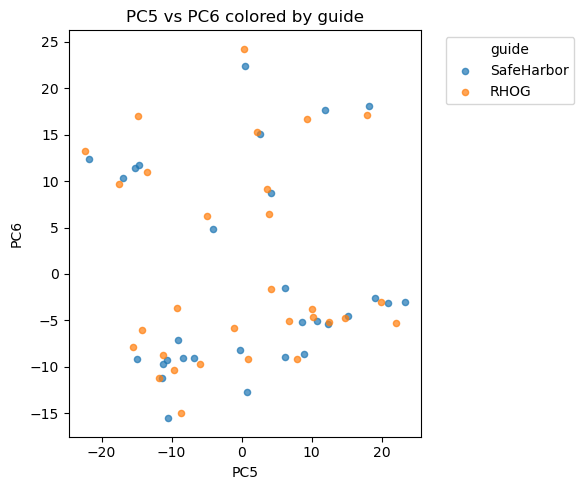

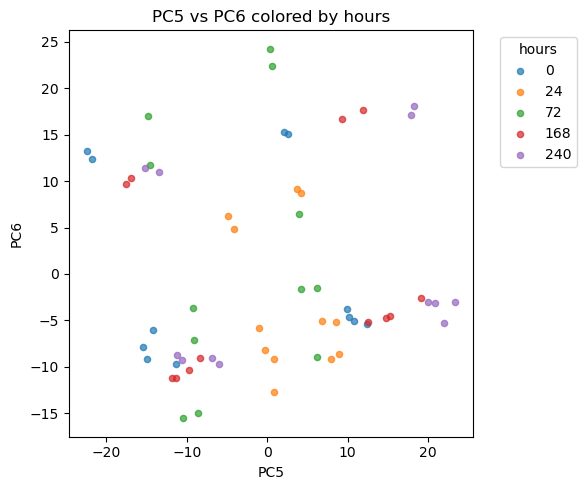

In [7]:
#Cell 3 – Basic PCA summary plots (PC5/PC6, etc.)
#You can add a PC1/PC2 simple scatter similarly if you like.
# PC5 vs PC6 colored by guide
plot_pca_scatter(
    scores_df=scores_df,
    meta=metadata,
    pc_x="PC5",
    pc_y="PC6",
    color_by="guide",
    out_path=PCA_RESULTS_DIR / "PCA_summary_PC5_PC6_by_guide.png",
)

# PC5 vs PC6 colored by hours
plot_pca_scatter(
    scores_df=scores_df,
    meta=metadata,
    pc_x="PC5",
    pc_y="PC6",
    color_by="hours",
    out_path=PCA_RESULTS_DIR / "PCA_summary_PC5_PC6_by_hours.png",
)


In [8]:
#Cell 4  – Build meta_pca (used for biology figure)
meta_pca = metadata.join(scores_df[["PC1", "PC2"]], how="left")
meta_pca.head()


,GSM,title,cell_type,hours,guide,donor,PC1,PC2
sample_id,,,,,,,,
CART0077_RNAseq_NgsRun1_001,"""GSM8252546""","""CD4, 0h, SafeHarbor, CART0077_D1""",CD4,0,SafeHarbor,CART0077_D1,-36.608980,-31.024521
CART0077_RNAseq_NgsRun1_002,"""GSM8252547""","""CD4, 0h, RHOG, CART0077_D1""",CD4,0,RHOG,CART0077_D1,-38.726879,-31.195909
CART0077_RNAseq_NgsRun1_003,"""GSM8252548""","""CD4, 0h, SafeHarbor, CART0077_D2""",CD4,0,SafeHarbor,CART0077_D2,-30.944237,-29.247542
CART0077_RNAseq_NgsRun1_004,"""GSM8252549""","""CD4, 0h, RHOG, CART0077_D2""",CD4,0,RHOG,CART0077_D2,-39.028631,-31.262182
CART0077_RNAseq_NgsRun1_005,"""GSM8252550""","""CD4, 0h, SafeHarbor, CART0077_D3""",CD4,0,SafeHarbor,CART0077_D3,-39.389334,-32.215399


In [9]:
# #Cell 5 Define the biological PC1/PC2 plot helper
def plot_biological_pca_pc1_pc2(
    meta_pca: pd.DataFrame,
    out_name: str = "PCA_biological_interpretation_PC1_PC2.png",
):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(8, 7))

    color_map = {
        "RHOG": "darkorange",
        "SafeHarbor": "steelblue",
    }

    # Plot samples by guide
    for cond in meta_pca["guide"].unique():
        mask = meta_pca["guide"] == cond
        ax.scatter(
            meta_pca.loc[mask, "PC1"],
            meta_pca.loc[mask, "PC2"],
            s=90,
            alpha=0.8,
            edgecolor="k",
            label=cond,
            c=color_map.get(cond, "gray"),
        )

    # Time-ordered arrows
    for cond in meta_pca["guide"].unique():
        df = meta_pca[meta_pca["guide"] == cond].sort_values("hours")
        for i in range(len(df) - 1):
            x1, y1 = df.iloc[i][["PC1", "PC2"]]
            x2, y2 = df.iloc[i + 1][["PC1", "PC2"]]
            ax.arrow(
                x1, y1,
                x2 - x1,
                y2 - y1,
                color=color_map.get(cond, "gray"),
                alpha=0.6,
                width=0.002,
                length_includes_head=True,
            )

    x_min, x_max = meta_pca["PC1"].min(), meta_pca["PC1"].max()
    y_min, y_max = meta_pca["PC2"].min(), meta_pca["PC2"].max()

    ax.axvline(0, color="k", linewidth=0.6, alpha=0.6)
    ax.axhline(0, color="k", linewidth=0.6, alpha=0.6)

    ax.text(x_min * 0.75, y_max * 0.97,
            "Effector / IL2–STAT5\nInflammatory Activation",
            fontsize=10, ha="center")
    ax.text(x_max * 0.7, y_max * 0.9,
            "Interferon-High\nStress Activation",
            fontsize=10, ha="center")
    ax.text(x_min * 0.8, y_min * 0.8,
            "Proliferative / E2F\nOxPhos Programs",
            fontsize=10, ha="center")
    ax.text(x_max * 0.7, y_min * 0.9,
            "IFN-biased\nLow Activation",
            fontsize=10, ha="center")

    ax.set_xlabel(
        "PC1: Effector IL2/STAT5 & NFκB Activation  ↔  Interferon-driven Activation",
        fontsize=11,
    )
    ax.set_ylabel(
        "PC2: Interferon-stress  ↔  Proliferation/E2F axis",
        fontsize=11,
    )
    ax.set_title("PCA — Biological Interpretation of Activation Trajectories", fontsize=14)

    ax.legend(
        frameon=True,
        loc="lower left",
        bbox_to_anchor=(0.5, 0.04)
    )

    ax.grid(alpha=0.25)
    fig.tight_layout()

    out_path = PCA_RESULTS_DIR / out_name
    fig.savefig(out_path, dpi=300, bbox_inches="tight")

    plt.show()        # 👈 THIS is the missing line
    return out_path



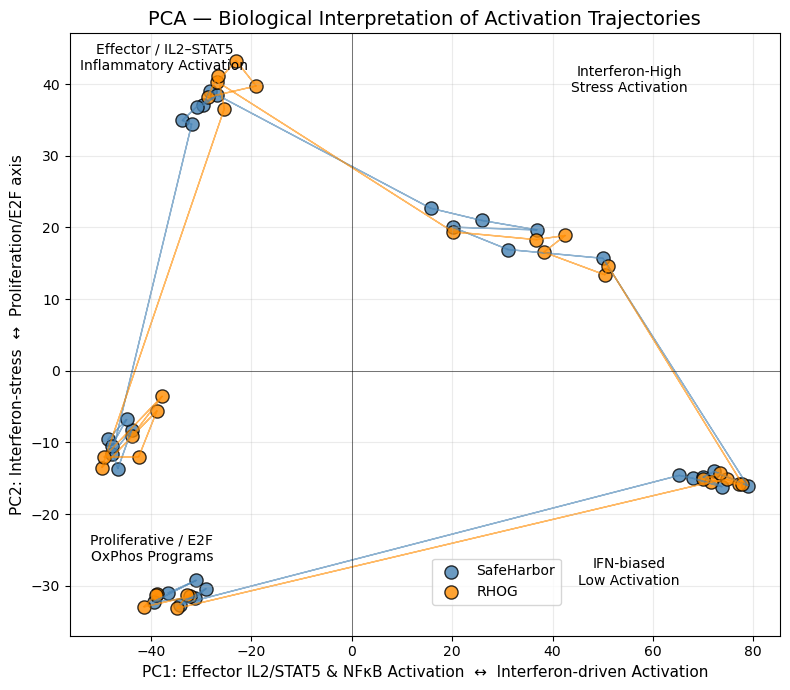

PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/pca/PCA_biological_interpretation_PC1_PC2.png')

In [10]:
#Cell 6 – Call the biological figure once
bio_pca_path = plot_biological_pca_pc1_pc2(meta_pca)
bio_pca_path

In [11]:
def plot_biological_pca_pc1_pc2(
    meta_pca: pd.DataFrame,
    out_name: str = "PCA_biological_interpretation_PC1_PC2.png",
):
    import numpy as np
    import matplotlib.pyplot as plt

    # ---- Safety checks ----
    required_cols = {"PC1", "PC2", "guide", "hours"}
    missing = required_cols - set(meta_pca.columns)
    if missing:
        raise ValueError(f"meta_pca is missing required columns: {missing}")

    # ---- Figure setup ----
    fig, ax = plt.subplots(figsize=(8, 7))

    color_map = {
        "SafeHarbor": "steelblue",
        "RHOG": "darkorange",
    }

    # ---- Plot individual samples (faint, honest background) ----
    for cond in meta_pca["guide"].unique():
        mask = meta_pca["guide"] == cond
        ax.scatter(
            meta_pca.loc[mask, "PC1"],
            meta_pca.loc[mask, "PC2"],
            s=50,
            alpha=0.35,
            edgecolor="none",
            c=color_map.get(cond, "gray"),
        )

    # ---- Compute and plot centroid trajectories ----
    for cond in meta_pca["guide"].unique():
        dfc = (
            meta_pca[meta_pca["guide"] == cond]
            .groupby("hours")[["PC1", "PC2"]]
            .mean()
            .reset_index()
            .sort_values("hours")
        )

        ax.plot(
            dfc["PC1"],
            dfc["PC2"],
            "-o",
            linewidth=2.2,
            markersize=8,
            alpha=0.95,
            color=color_map.get(cond, "gray"),
            label=cond,
        )

    # ---- Axes reference lines ----
    ax.axvline(0, color="black", linewidth=0.6, alpha=0.6)
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)

    # ---- Axis limits & padding ----
    x_min, x_max = meta_pca["PC1"].min(), meta_pca["PC1"].max()
    y_min, y_max = meta_pca["PC2"].min(), meta_pca["PC2"].max()
    x_pad = 0.05 * (x_max - x_min)
    y_pad = 0.05 * (y_max - y_min)

    # ---- Quadrant biological annotations ----
    ax.text(x_min * 0.75, y_max * 0.97,
        "Effector / IL2–STAT5\nInflammatory Activation",
        fontsize=10, ha="center")

    ax.text(
        x_max - x_pad,
        y_max - y_pad,
        "Interferon-High\nStress Activation",
        fontsize=10,
        ha="right",
        va="top",
    )

    ax.text(
        x_min + x_pad,
        y_min + y_pad,
        "Proliferative / E2F\nOxPhos Programs",
        fontsize=10,
        ha="left",
        va="bottom",
    )

    ax.text(
        x_max - x_pad,
        y_min + y_pad,
        "IFN-biased\nLow Activation",
        fontsize=10,
        ha="right",
        va="bottom",
    )

    # ---- Labels & styling ----
    ax.set_xlabel(
        "PC1: Effector IL2/STAT5 & NFκB Activation  ↔  Interferon-driven Activation",
        fontsize=11,
    )
    ax.set_ylabel(
        "PC2: Interferon-stress  ↔  Proliferation / E2F axis",
        fontsize=11,
    )

    ax.set_title(
        "PCA — Biological Interpretation of Activation Trajectories",
        fontsize=14,
    )

    ax.legend(
    frameon=True,
    loc="lower left",
    bbox_to_anchor=(0.5, 0.05)
)
    ax.grid(alpha=0.25)

    fig.tight_layout()

    # ---- Save ----
    out_path = PCA_RESULTS_DIR / out_name
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    
    
    plt.show()   
    return out_path

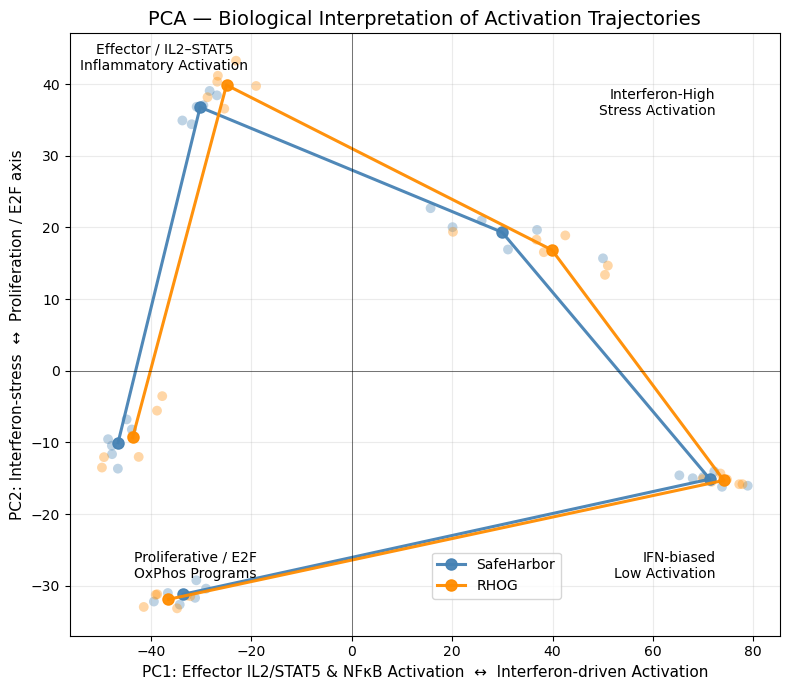

PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/pca/PCA_biological_interpretation_PC1_PC2.png')

In [12]:
#Cell 6 – Call the biological figure once
bio_pca_path = plot_biological_pca_pc1_pc2(meta_pca)
bio_pca_path

In [13]:
def plot_biological_pca_pc1_pc2_centroids(
    meta_pca: pd.DataFrame,
    out_name: str = "PCA_biological_interpretation_PC1_PC2.png",
    show: bool = True,
):
    import numpy as np
    import matplotlib.pyplot as plt

    # ---- checks ----
    required = {"PC1", "PC2", "guide", "hours"}
    missing = required - set(meta_pca.columns)
    if missing:
        raise ValueError(f"meta_pca missing columns: {missing}")

    fig, ax = plt.subplots(figsize=(8, 7))

    color_map = {
        "SafeHarbor": "steelblue",
        "RHOG": "darkorange",
    }

    # ---- background: individual samples (faint) ----
    for cond in meta_pca["guide"].unique():
        mask = meta_pca["guide"] == cond
        ax.scatter(
            meta_pca.loc[mask, "PC1"],
            meta_pca.loc[mask, "PC2"],
            s=45,
            alpha=0.30,
            edgecolor="none",
            c=color_map.get(cond, "gray"),
            zorder=1,
        )

    # ---- centroids + arrows (main story) ----
    for cond in meta_pca["guide"].unique():
        dfc = (
            meta_pca[meta_pca["guide"] == cond]
            .groupby("hours")[["PC1", "PC2"]]
            .mean()
            .reset_index()
            .sort_values("hours")
            .reset_index(drop=True)
        )

        col = color_map.get(cond, "gray")

        # line + markers for centroids
        ax.plot(
            dfc["PC1"],
            dfc["PC2"],
            "-o",
            linewidth=2.2,
            markersize=8,
            alpha=0.95,
            color=col,
            label=cond,
            zorder=3,
        )

        # arrowheads between successive centroids
        for i in range(len(dfc) - 1):
            x1, y1 = dfc.loc[i, ["PC1", "PC2"]]
            x2, y2 = dfc.loc[i + 1, ["PC1", "PC2"]]

            ax.annotate(
                "", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=col,
                    lw=2.2,
                    alpha=0.95,
                    mutation_scale=20,  # arrowhead size (try 14–20)
                    shrinkA=0,
                    shrinkB=0,
                ),
                zorder=4,
            )

    # ---- axes reference lines ----
    ax.axvline(0, color="black", linewidth=0.6, alpha=0.6, zorder=0)
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.6, zorder=0)

    # ---- bounds + padding for labels ----
    x_min, x_max = meta_pca["PC1"].min(), meta_pca["PC1"].max()
    y_min, y_max = meta_pca["PC2"].min(), meta_pca["PC2"].max()
    x_pad = 0.05 * (x_max - x_min)
    y_pad = 0.05 * (y_max - y_min)

    # ---- quadrant biological labels ----
    ax.text(
        x_min + x_pad, y_max - y_pad,
        "Effector / IL2–STAT5\nInflammatory Activation",
        fontsize=10, ha="left", va="top"
    )
    ax.text(
        x_max - x_pad, y_max - y_pad,
        "Interferon-High\nStress Activation",
        fontsize=10, ha="right", va="top"
    )
    ax.text(
        x_min + x_pad, y_min + y_pad,
        "Proliferative / E2F\nOxPhos Programs",
        fontsize=10, ha="left", va="bottom"
    )
    ax.text(
        x_max - x_pad, y_min + y_pad,
        "IFN-biased\nLow Activation",
        fontsize=10, ha="right", va="bottom"
    )

    # ---- labels ----
    ax.set_xlabel(
        "PC1: Effector IL2/STAT5 & NFκB Activation  ↔  Interferon-driven Activation",
        fontsize=11
    )
    ax.set_ylabel(
        "PC2: Interferon-stress  ↔  Proliferation / E2F axis",
        fontsize=11
    )
    ax.set_title("PCA — Biological Interpretation of Activation Trajectories", fontsize=14)

    # ---- legend: move it so it doesn't cover quadrant text ----
    ax.legend(
        frameon=True,
        loc="lower left",
        bbox_to_anchor=(0.62, 0.05)
    )

    # ---- micro-legend for arrows (optional but recommended) ----
    ax.text(
        0.98, 0.02,
        "Arrowheads indicate temporal progression (early → late)",
        transform=ax.transAxes,
        fontsize=9,
        ha="right",
        va="bottom",
        color="gray",
    )

    ax.grid(alpha=0.25)
    fig.tight_layout()

    # ---- save ----
    out_path = PCA_RESULTS_DIR / out_name
    fig.savefig(out_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path


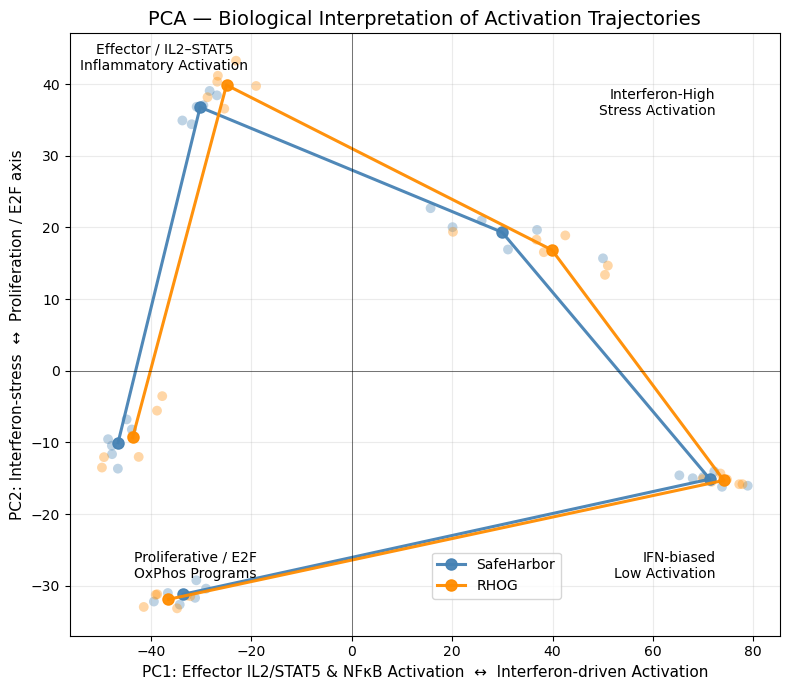

PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/pca/PCA_biological_interpretation_PC1_PC2.png')

In [14]:
#Cell 6 – Call the biological figure once
bio_pca_path = plot_biological_pca_pc1_pc2(meta_pca)
bio_pca_path

In [41]:
# “Run Everything” cell
def run_full_pca_pipeline():
    # 1. Load inputs
    expr_symbol = pd.read_parquet(PROCESSED_DIR / "expr_logcpm_symbol.parquet")
    metadata    = pd.read_csv(PROCESSED_DIR / "metadata_samples.csv", index_col=0)

    # 2. Run PCA
    scores_df, loadings_df, explained_df, pca = run_pca(
        expr_symbol,
        n_components=20,
        center=True,
        scale=False,
        random_state=0,
    )

    # 3. Save PCA outputs
    save_pca_results(
        scores_df=scores_df,
        loadings_df=loadings_df,
        explained_df=explained_df,
        out_dir=PCA_RESULTS_DIR,
    )

    # 4. Attach PCs to metadata
    meta_pca = metadata.join(scores_df[["PC1", "PC2"]], how="left")

    # 5. Save meta_pca for reuse
    modules_dir = RESULTS_DIR / "modules"
    ensure_dirs(modules_dir)
    meta_pca.to_csv(modules_dir / "metadata_with_PC1_PC2.csv")

    # 6. PCA summary plots
    plot_pca_scatter(
        scores_df=scores_df,
        meta=metadata,
        pc_x="PC5",
        pc_y="PC6",
        color_by="guide",
        out_path=PCA_RESULTS_DIR / "PCA_summary_PC5_PC6_by_guide.png",
    )
    plot_pca_scatter(
        scores_df=scores_df,
        meta=metadata,
        pc_x="PC5",
        pc_y="PC6",
        color_by="hours",
        out_path=PCA_RESULTS_DIR / "PCA_summary_PC5_PC6_by_hours.png",
    )

    # 7. Biological PC1/PC2 interpretive figure
    plot_biological_pca_pc1_pc2(meta_pca)

    return scores_df, loadings_df, explained_df, meta_pca


In [21]:
from analysis_utils.config_utils import PROCESSED_DIR
import pandas as pd

metadata = pd.read_csv(PROCESSED_DIR / "metadata_samples.csv", index_col=0)
metadata.head()


ModuleNotFoundError: No module named 'analysis_utils'

In [22]:
scores_df, loadings_df, explained_df, pca = run_pca(expr_symbol)


NameError: name 'run_pca' is not defined

In [23]:
from analysis_utils.config_utils import (
    PROJECT_ROOT,
    PROCESSED_DIR,
    RESULTS_DIR,
    PCA_RESULTS_DIR,
)


ModuleNotFoundError: No module named 'analysis_utils'

In [148]:
from pathlib import Path
import sys

# Absolute path to your project root
PROJECT_ROOT = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis")

# Make sure Python can see analysis_utils
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT on sys.path:", PROJECT_ROOT in map(Path, sys.path))


PROJECT_ROOT on sys.path: True


In [149]:
from pathlib import Path
import sys
import pandas as pd

from analysis_utils.config_utils import (
    PROJECT_ROOT,
    PROCESSED_DIR,
    RESULTS_DIR,
    PCA_RESULTS_DIR,
)

from analysis_utils.pca_utils import run_pca, save_pca_results, plot_pca_scatter


# Just to sanity-check:
PROJECT_ROOT, PROCESSED_DIR, PCA_RESULTS_DIR


(PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis'),
 PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/data/processed'),
 PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/pca'))

In [150]:
# Either recompute
scores_df, loadings_df, explained_df, pca = run_pca(expr_symbol)

# or load from disk if already saved
# scores_df = pd.read_parquet(PCA_RESULTS_DIR / "pca_scores.parquet")
# loadings_df = pd.read_parquet(PCA_RESULTS_DIR / "pca_loadings.parquet")

# Attach PCs to metadata
# If you already have meta_with_pcs saved, you can load it; otherwise:
meta_pca = metadata.join(scores_df[["PC1", "PC2"]], how="left")
meta_pca.head()


,GSM,title,cell_type,hours,guide,donor,PC1,PC2
sample_id,,,,,,,,
CART0077_RNAseq_NgsRun1_001,"""GSM8252546""","""CD4, 0h, SafeHarbor, CART0077_D1""",CD4,0,SafeHarbor,CART0077_D1,-36.608980,-31.024521
CART0077_RNAseq_NgsRun1_002,"""GSM8252547""","""CD4, 0h, RHOG, CART0077_D1""",CD4,0,RHOG,CART0077_D1,-38.726879,-31.195909
CART0077_RNAseq_NgsRun1_003,"""GSM8252548""","""CD4, 0h, SafeHarbor, CART0077_D2""",CD4,0,SafeHarbor,CART0077_D2,-30.944237,-29.247542
CART0077_RNAseq_NgsRun1_004,"""GSM8252549""","""CD4, 0h, RHOG, CART0077_D2""",CD4,0,RHOG,CART0077_D2,-39.028631,-31.262182
CART0077_RNAseq_NgsRun1_005,"""GSM8252550""","""CD4, 0h, SafeHarbor, CART0077_D3""",CD4,0,SafeHarbor,CART0077_D3,-39.389334,-32.215399


In [151]:
from analysis_utils.config_utils import PCA_RESULTS_DIR, ensure_dirs
ensure_dirs(PCA_RESULTS_DIR)

def plot_biological_pca_pc1_pc2(meta_pca, out_name="PCA_biological_interpretation_PC1_PC2.png"):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(8, 7))

    color_map = {
        "RHOG": "darkorange",
        "SafeHarbor": "steelblue",
    }

    # Samples colored by guide/perturbation
    for cond in meta_pca["guide"].unique():
        mask = meta_pca["guide"] == cond
        ax.scatter(
            meta_pca.loc[mask, "PC1"],
            meta_pca.loc[mask, "PC2"],
            s=90, alpha=0.8, edgecolor="k",
            label=cond,
            c=color_map.get(cond, "gray"),
        )

    # Time-ordered arrows within each guide
    for cond in meta_pca["guide"].unique():
        df = meta_pca[meta_pca["guide"] == cond].sort_values("hours")
        for i in range(len(df) - 1):
            x1, y1 = df.iloc[i][["PC1", "PC2"]]
            x2, y2 = df.iloc[i + 1][["PC1", "PC2"]]
            ax.arrow(
                x1, y1, x2 - x1, y2 - y1,
                color=color_map.get(cond, "gray"),
                alpha=0.6,
                width=0.002,
                length_includes_head=True,
            )

    x_min, x_max = meta_pca["PC1"].min(), meta_pca["PC1"].max()
    y_min, y_max = meta_pca["PC2"].min(), meta_pca["PC2"].max()

    ax.axvline(0, color="k", linewidth=0.6, alpha=0.6)
    ax.axhline(0, color="k", linewidth=0.6, alpha=0.6)

    # Quadrant biology labels
    ax.text(x_min * 0.7, y_max * 0.9,
            "Effector / IL2–STAT5\nInflammatory Activation",
            fontsize=10, ha="center")
    ax.text(x_max * 0.7, y_max * 0.9,
            "Interferon-High\nStress Activation",
            fontsize=10, ha="center")
    ax.text(x_min * 0.7, y_min * 0.9,
            "Proliferative / E2F\nOxPhos Programs",
            fontsize=10, ha="center")
    ax.text(x_max * 0.7, y_min * 0.9,
            "IFN-biased\nLow Activation",
            fontsize=10, ha="center")

    ax.set_xlabel("PC1: Effector IL2/STAT5 & NFκB Activation  \u2194  Interferon-driven Activation",
                  fontsize=11)
    ax.set_ylabel("PC2: Interferon-stress  \u2194  Proliferation/E2F axis",
                  fontsize=11)
    ax.set_title("PCA — CRISPR Perturbation", fontsize=14)
    ax.legend(loc="lower left", frameon=True)
    ax.grid(alpha=0.15)
    fig.tight_layout()

    out_path = PCA_RESULTS_DIR / out_name
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    return out_path


PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/pca/PCA_biological_interpretation_PC1_PC2.png')

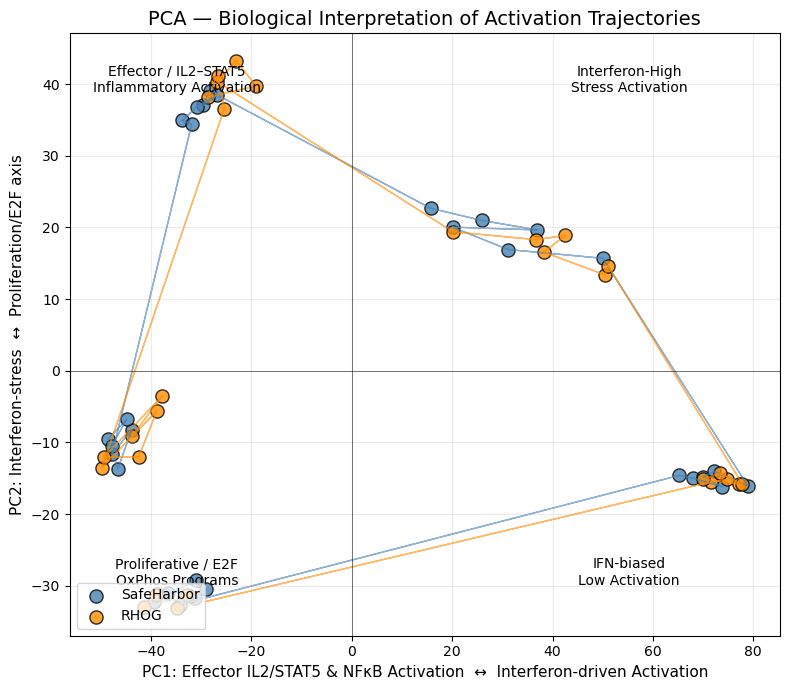

In [152]:
bio_pca_path = plot_biological_pca_pc1_pc2(meta_pca)
bio_pca_path


In [153]:
import analysis_utils
analysis_utils.__file__


'/Users/acastano/Desktop/crispr_carT_AI_analysis/analysis_utils/__init__.py'

In [154]:
expr_logcpm = pd.read_parquet(PROCESSED_DIR / "expr_logcpm.parquet")

In [155]:
mapping_df = pd.read_csv(PROCESSED_DIR / "ensg_to_symbol.csv")
ensg_to_symbol = dict(zip(mapping_df["ensembl"], mapping_df["symbol"]))


In [156]:
from analysis_utils.module_pipeline import map_expression_to_symbols
expr_symbol = map_expression_to_symbols(expr_logcpm, ensg_to_symbol)



In [157]:
meta = pd.read_csv(PROCESSED_DIR / "metadata_samples.csv", index_col=0)
expr_symbol.columns == meta.index

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

In [158]:
from analysis_utils.module_pipeline import map_expression_to_symbols

# Build mapping dict from the CSV
ensg_to_symbol = dict(zip(mapping_df["ensembl"], mapping_df["symbol"]))

# Apply ENSG → SYMBOL mapping
expr_symbol = map_expression_to_symbols(expr_logcpm, ensg_to_symbol)

expr_symbol.head()

,CART0077_RNAseq_NgsRun1_001,CART0077_RNAseq_NgsRun1_002,CART0077_RNAseq_NgsRun1_003,CART0077_RNAseq_NgsRun1_004,CART0077_RNAseq_NgsRun1_005,CART0077_RNAseq_NgsRun1_006,CART0077_RNAseq_NgsRun1_007,CART0077_RNAseq_NgsRun1_008,CART0077_RNAseq_NgsRun1_009,CART0077_RNAseq_NgsRun1_010,...,CART0077_RNAseq_NgsRun1_051,CART0077_RNAseq_NgsRun1_052,CART0077_RNAseq_NgsRun1_053,CART0077_RNAseq_NgsRun1_054,CART0077_RNAseq_NgsRun1_055,CART0077_RNAseq_NgsRun1_056,CART0077_RNAseq_NgsRun1_057,CART0077_RNAseq_NgsRun1_058,CART0077_RNAseq_NgsRun1_059,CART0077_RNAseq_NgsRun1_060
gene_symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,0.063729,0.233937,0.230089,0.027546,0.140237,0.083679,0.119019,0.104961,0.031403,0.064387,...,0.291773,0.210028,0.263343,0.145059,0.500513,0.336267,0.141521,0.201050,0.156030,0.231409
A1BG-AS1,2.294187,2.301634,2.025882,2.125033,1.916338,2.028702,2.328075,2.420824,2.225959,2.401735,...,2.505373,2.543098,2.552231,2.475571,2.780749,2.781865,2.744467,2.767573,2.636810,2.676867
A1CF,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.061682,0.000000,0.000000
A2M,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.042139,0.000000,0.000000,0.000000,0.000000,0.000000,0.033215,0.000000
A2M-AS1,0.000000,0.000000,0.000000,0.000000,0.203609,0.135813,0.000000,0.071183,0.000000,0.000000,...,0.156490,0.000000,0.158845,0.210391,0.000000,0.000000,0.000000,0.031317,0.363976,0.352843


In [159]:
scores_df, loadings_df, explained_df, pca = run_pca(
    expr_symbol,
    n_components=20,
    center=True,
    scale=False,
    random_state=0,
)



scores_df.head(), loadings_df.shape, explained_df


(                                   PC1        PC2        PC3       PC4  \
 CART0077_RNAseq_NgsRun1_001 -36.608980 -31.024521 -11.759580 -2.347379   
 CART0077_RNAseq_NgsRun1_002 -38.726879 -31.195909 -10.533219 -3.004145   
 CART0077_RNAseq_NgsRun1_003 -30.944237 -29.247542 -16.600241 -0.461992   
 CART0077_RNAseq_NgsRun1_004 -39.028631 -31.262182 -11.640999 -3.257525   
 CART0077_RNAseq_NgsRun1_005 -39.389334 -32.215399  -9.875385 -7.902223   
 
                                    PC5        PC6        PC7       PC8  \
 CART0077_RNAseq_NgsRun1_001 -14.999687  -9.153062  -2.259850  7.547892   
 CART0077_RNAseq_NgsRun1_002 -15.452616  -7.875105  -2.334574  9.496644   
 CART0077_RNAseq_NgsRun1_003 -11.289210  -9.726801  11.787962 -3.684116   
 CART0077_RNAseq_NgsRun1_004 -14.183817  -6.049385  12.044974  2.646580   
 CART0077_RNAseq_NgsRun1_005 -21.834669  12.375365  -1.941011 -1.475373   
 
                                    PC9      PC10      PC11      PC12  \
 CART0077_RNAseq_NgsRun

In [160]:
save_pca_results(
    scores_df=scores_df,
    loadings_df=loadings_df,
    explained_df=explained_df,
    out_dir=PCA_RESULTS_DIR,
)


In [161]:
# Identify any existing PC columns in meta
pc_cols_in_meta = [c for c in meta.columns if c.startswith("PC")]

# Drop them (if none exist, errors="ignore" keeps it safe)
meta_clean = meta.drop(columns=pc_cols_in_meta, errors="ignore")

# Now join the fresh scores
meta_with_pcs = meta_clean.join(scores_df, how="left")

meta_with_pcs.head()




,GSM,title,cell_type,hours,guide,donor,PC1,PC2,PC3,PC4,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
sample_id,,,,,,,,,,,,,,,,,,,,,
CART0077_RNAseq_NgsRun1_001,"""GSM8252546""","""CD4, 0h, SafeHarbor, CART0077_D1""",CD4,0,SafeHarbor,CART0077_D1,-36.608980,-31.024521,-11.759580,-2.347379,...,-1.783244,-8.906770,3.175437,-1.220633,-3.416751,-0.973683,-2.629760,0.304593,0.669344,3.532576
CART0077_RNAseq_NgsRun1_002,"""GSM8252547""","""CD4, 0h, RHOG, CART0077_D1""",CD4,0,RHOG,CART0077_D1,-38.726879,-31.195909,-10.533219,-3.004145,...,-1.787556,-5.944062,1.334272,-0.640531,-2.797774,-2.614060,-2.349428,-0.284004,-1.433859,1.229688
CART0077_RNAseq_NgsRun1_003,"""GSM8252548""","""CD4, 0h, SafeHarbor, CART0077_D2""",CD4,0,SafeHarbor,CART0077_D2,-30.944237,-29.247542,-16.600241,-0.461992,...,0.512577,-6.636773,1.566247,-1.428228,6.346484,2.799048,-2.150189,2.857538,2.966854,-0.384266
CART0077_RNAseq_NgsRun1_004,"""GSM8252549""","""CD4, 0h, RHOG, CART0077_D2""",CD4,0,RHOG,CART0077_D2,-39.028631,-31.262182,-11.640999,-3.257525,...,-1.192829,-1.065661,-0.963558,1.489930,4.656184,-0.559286,0.721092,2.426362,-3.893079,-3.277492
CART0077_RNAseq_NgsRun1_005,"""GSM8252550""","""CD4, 0h, SafeHarbor, CART0077_D3""",CD4,0,SafeHarbor,CART0077_D3,-39.389334,-32.215399,-9.875385,-7.902223,...,-2.504313,4.270357,-1.501922,-1.624859,1.213262,-0.304563,2.625938,-0.861574,1.818906,-0.198254


In [162]:
meta_with_pcs = meta.join(scores_df, how="left")

meta_out_dir = RESULTS_DIR / "modules"
meta_out_dir.mkdir(parents=True, exist_ok=True)

meta_with_pcs.to_parquet(meta_out_dir / "metadata_with_pcs.parquet")
meta_with_pcs.to_csv(meta_out_dir / "metadata_with_pcs.csv")


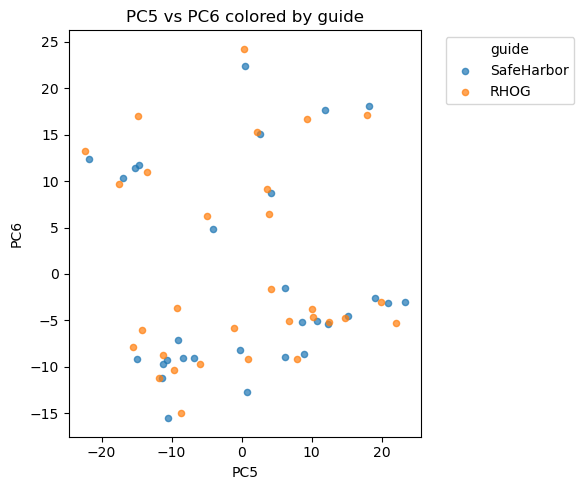

In [163]:
fig_path = PCA_RESULTS_DIR / "fig_pca_PC5_PC6_by_guide.png"

fig, ax = plot_pca_scatter(
    scores_df=scores_df,
    meta=meta,
    pc_x="PC5",
    pc_y="PC6",
    color_by="guide",
    out_path=fig_path,
)


(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'PC5 vs PC6 colored by hours'}, xlabel='PC5', ylabel='PC6'>)

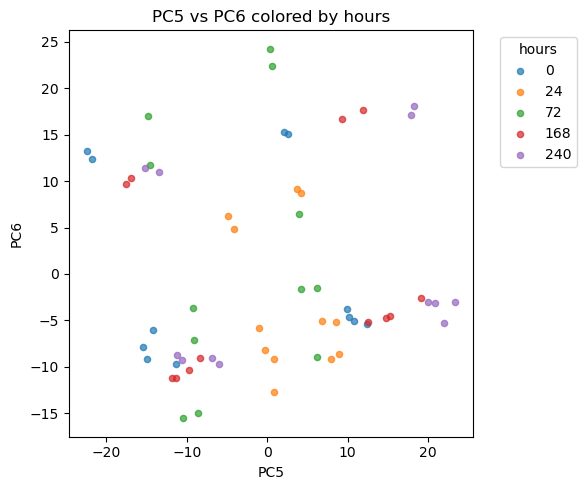

In [164]:
fig_path2 = PCA_RESULTS_DIR / "fig_pca_PC5_PC6_by_hours.png"

plot_pca_scatter(
    scores_df=scores_df,
    meta=meta,
    pc_x="PC5",
    pc_y="PC6",
    color_by="hours",
    out_path=fig_path2,
)


In [165]:
meta.index.equals(scores_df.index)


True

In [166]:
scores_df, loadings_df, explained_df, pca = run_pca(
    expr_symbol,
    n_components=20,   # or whatever you want
    center=True,
    scale=False,
    random_state=0,
)

scores_df.head()




,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
CART0077_RNAseq_NgsRun1_001,-36.608980,-31.024521,-11.759580,-2.347379,-14.999687,-9.153062,-2.259850,7.547892,-5.554881,2.444653,-1.783244,-8.906770,3.175437,-1.220633,-3.416751,-0.973683,-2.629760,0.304593,0.669344,3.532576
CART0077_RNAseq_NgsRun1_002,-38.726879,-31.195909,-10.533219,-3.004145,-15.452616,-7.875105,-2.334574,9.496644,-6.437116,3.754927,-1.787556,-5.944062,1.334272,-0.640531,-2.797774,-2.614060,-2.349428,-0.284004,-1.433859,1.229688
CART0077_RNAseq_NgsRun1_003,-30.944237,-29.247542,-16.600241,-0.461992,-11.289210,-9.726801,11.787962,-3.684116,-3.660495,-2.790931,0.512577,-6.636773,1.566247,-1.428228,6.346484,2.799048,-2.150189,2.857538,2.966854,-0.384266
CART0077_RNAseq_NgsRun1_004,-39.028631,-31.262182,-11.640999,-3.257525,-14.183817,-6.049385,12.044974,2.646580,-7.590086,2.380308,-1.192829,-1.065661,-0.963558,1.489930,4.656184,-0.559286,0.721092,2.426362,-3.893079,-3.277492
CART0077_RNAseq_NgsRun1_005,-39.389334,-32.215399,-9.875385,-7.902223,-21.834669,12.375365,-1.941011,-1.475373,-10.674327,2.484162,-2.504313,4.270357,-1.501922,-1.624859,1.213262,-0.304563,2.625938,-0.861574,1.818906,-0.198254


/var/folders/qx/x9q1q3ns1hl9156prswwpk5m0000gn/T/ipykernel_67621/3842352609.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(explained_df["PC"], rotation=45)


PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/pca/summary_PCA_figure.png')

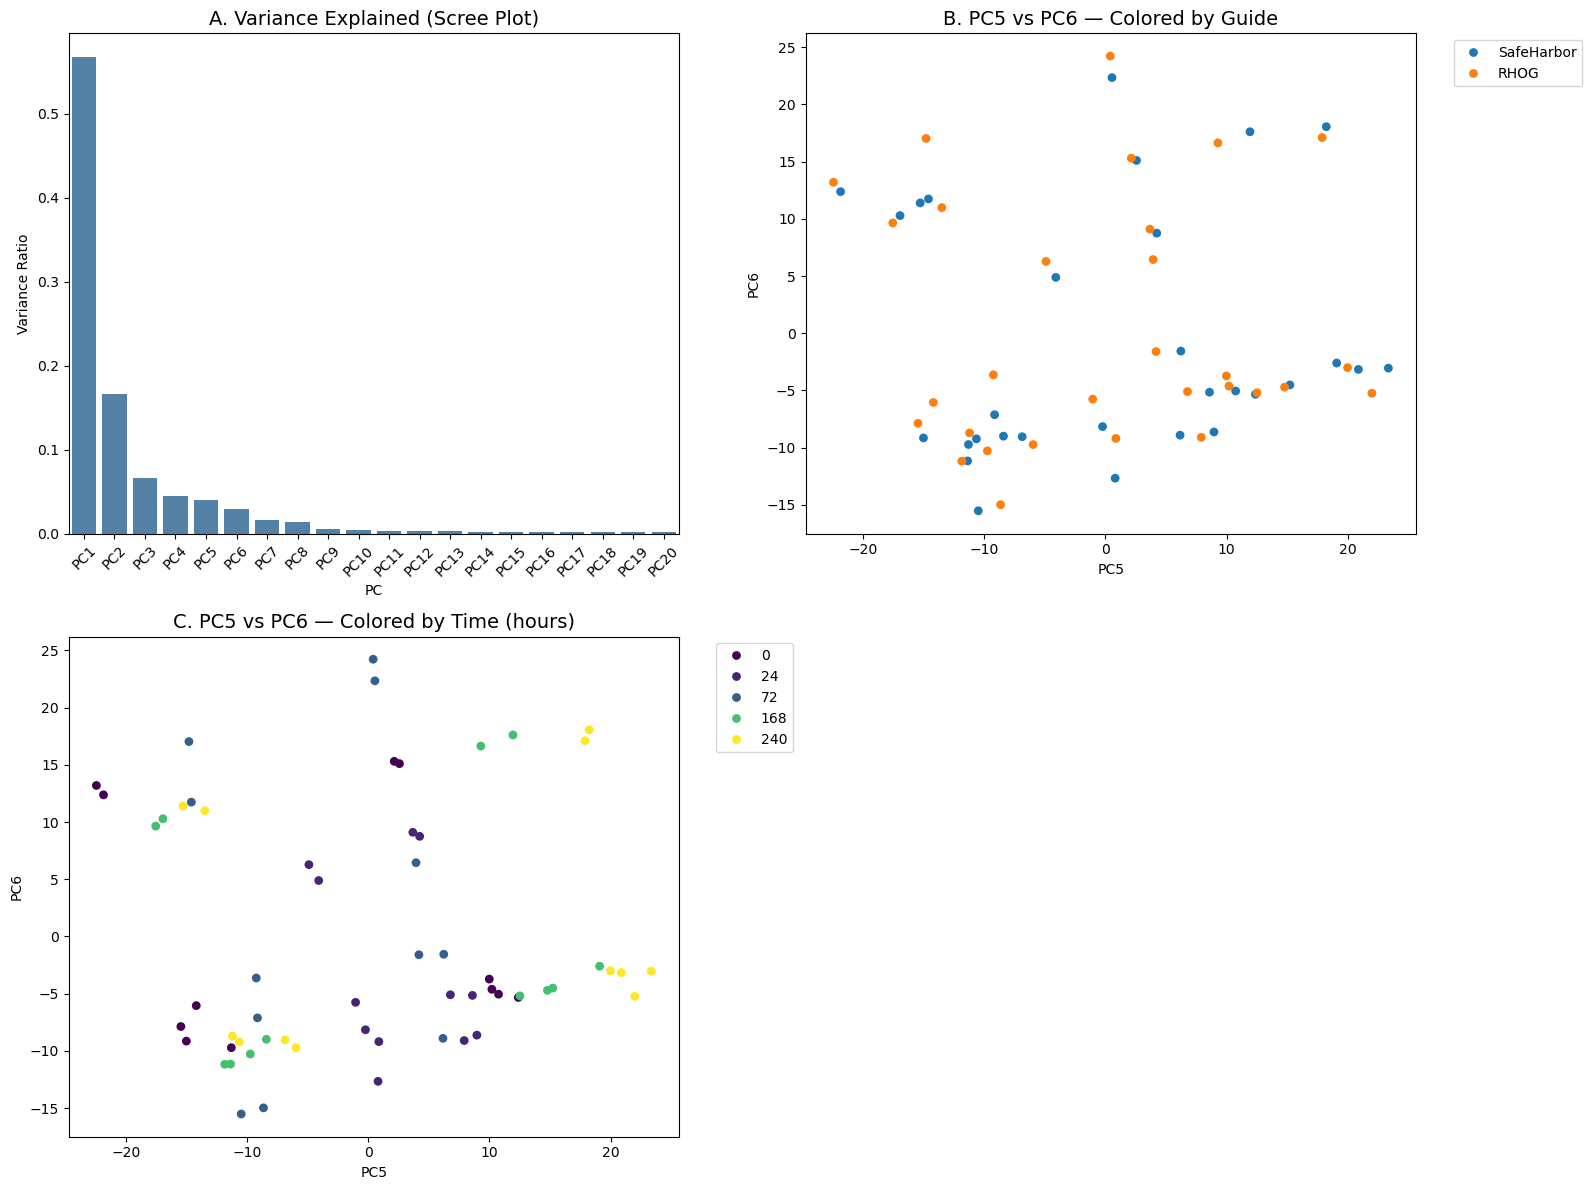

In [167]:
#Summary PCA Figure — Complete Code Block
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load PCA results (in case running fresh)
scores_df = pd.read_parquet(PCA_RESULTS_DIR / "pca_scores.parquet")
loadings_df = pd.read_parquet(PCA_RESULTS_DIR / "pca_loadings.parquet")
explained_df = pd.read_csv(PCA_RESULTS_DIR / "pca_explained_variance.csv")

# Ensure metadata is aligned
meta = meta.loc[scores_df.index]

# ----------------------------------------------------------------
# Build summary figure (3 panels)
# ----------------------------------------------------------------

fig = plt.figure(figsize=(16, 12))

########################
# Panel A – Scree plot
########################
ax1 = plt.subplot(2, 2, 1)
sns.barplot(
    x="PC",
    y="explained_variance_ratio",
    data=explained_df,
    color="steelblue",
    ax=ax1,
)
ax1.set_title("A. Variance Explained (Scree Plot)", fontsize=14)
ax1.set_ylabel("Variance Ratio")
ax1.set_xticklabels(explained_df["PC"], rotation=45)

########################
# Panel B – PC5 × PC6 colored by guide
########################
ax2 = plt.subplot(2, 2, 2)
sns.scatterplot(
    x="PC5",
    y="PC6",
    hue=meta["guide"],
    palette="tab10",
    data=scores_df,
    s=40,
    edgecolor="none",
    ax=ax2,
)
ax2.set_title("B. PC5 vs PC6 — Colored by Guide", fontsize=14)
ax2.set_xlabel("PC5")
ax2.set_ylabel("PC6")
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

########################
# Panel C – PC5 × PC6 colored by time (hours)
########################
ax3 = plt.subplot(2, 2, 3)
sns.scatterplot(
    x="PC5",
    y="PC6",
    hue=meta["hours"],
    palette="viridis",
    data=scores_df,
    s=40,
    edgecolor="none",
    ax=ax3,
)
ax3.set_title("C. PC5 vs PC6 — Colored by Time (hours)", fontsize=14)
ax3.set_xlabel("PC5")
ax3.set_ylabel("PC6")
ax3.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

# Save figure
summary_path = PCA_RESULTS_DIR / "summary_PCA_figure.png"
plt.savefig(summary_path, dpi=300, bbox_inches="tight")

summary_path


In [169]:
import gseapy as gp

# Get Hallmark gene sets as a dict: { pathway_name: [genes...] }
hallmark_sets = gp.get_library("MSigDB_Hallmark_2020")
len(hallmark_sets)


50

In [170]:
def module_score(expr_df, gene_list):
    """
    expr_df: genes (symbols) x samples
    gene_list: list of gene symbols (Hallmark pathway)

    Returns: Series indexed by samples (module score per sample),
    or None if no genes overlap.
    """
    genes = [g for g in gene_list if g in expr_df.index]
    if len(genes) == 0:
        return None
    return expr_df.loc[genes].mean(axis=0)


In [171]:
pathways_of_interest = [
    "IL-2/STAT5 Signaling",
    "TNFA Signaling via NFKB",
    "Interferon Alpha Response",
    "Interferon Gamma Response",
    "Inflammatory Response",
    "Apoptosis",
    "E2F Targets",
    "G2M Checkpoint",
    "Oxidative Phosphorylation",
]

# Sanity: which of these exist in the library?
[pw for pw in pathways_of_interest if pw in hallmark_sets]


['IL-2/STAT5 Signaling',
 'Interferon Alpha Response',
 'Interferon Gamma Response',
 'Inflammatory Response',
 'Apoptosis',
 'E2F Targets',
 'Oxidative Phosphorylation']

In [172]:
scores = {}  # pathway_name -> Series(samples)

for pw in pathways_of_interest:
    if pw not in hallmark_sets:
        print(f"Skipping {pw}: not found in Hallmark library.")
        continue

    gene_list = hallmark_sets[pw]
    s = module_score(expr_symbol, gene_list)
    if s is None:
        print(f"{pw}: no overlapping genes in expr_symbol")
        continue

    # s is a Series (samples), we store it
    scores[pw] = s

# Quick check
len(scores), list(scores.keys())


Skipping TNFA Signaling via NFKB: not found in Hallmark library.
Skipping G2M Checkpoint: not found in Hallmark library.


(7,
 ['IL-2/STAT5 Signaling',
  'Interferon Alpha Response',
  'Interferon Gamma Response',
  'Inflammatory Response',
  'Apoptosis',
  'E2F Targets',
  'Oxidative Phosphorylation'])

In [173]:
# sample × 2 PCs
pc_df = scores_df[["PC1", "PC2"]].copy()
pc_df.head()


,PC1,PC2
CART0077_RNAseq_NgsRun1_001,-36.608980,-31.024521
CART0077_RNAseq_NgsRun1_002,-38.726879,-31.195909
CART0077_RNAseq_NgsRun1_003,-30.944237,-29.247542
CART0077_RNAseq_NgsRun1_004,-39.028631,-31.262182
CART0077_RNAseq_NgsRun1_005,-39.389334,-32.215399


In [174]:
# C. Hallmark–PC correlations → save as a results table
corr_rows = []
for pw, s in scores.items():
    s = s.reindex(pc_df.index)
    corr_pc1 = pc_df["PC1"].corr(s)
    corr_pc2 = pc_df["PC2"].corr(s)
    corr_rows.append((pw, corr_pc1, corr_pc2))

corr_df = pd.DataFrame(corr_rows, columns=["Pathway", "corr_PC1", "corr_PC2"])
corr_df = corr_df.sort_values("corr_PC1", ascending=False)
corr_df


,Pathway,corr_PC1,corr_PC2
3,Inflammatory Response,0.958999,-0.094939
0,IL-2/STAT5 Signaling,0.949222,-0.021961
4,Apoptosis,0.891660,0.130125
6,Oxidative Phosphorylation,0.833682,0.194009
5,E2F Targets,0.681968,0.035590
2,Interferon Gamma Response,-0.148222,-0.549863
1,Interferon Alpha Response,-0.487390,-0.647592


In [175]:
#"Just save it using your PATHWAY_RESULTS_DIR:
from analysis_utils.config_utils import RESULTS_DIR, ensure_dirs

PATHWAY_RESULTS_DIR = RESULTS_DIR / "pathways"
ensure_dirs(PATHWAY_RESULTS_DIR)

out_path = PATHWAY_RESULTS_DIR / "hallmark_pc_correlations_PC1_PC2.csv"
corr_df.to_csv(out_path, index=False)
out_path




PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/pathways/hallmark_pc_correlations_PC1_PC2.csv')

PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/pathways/hallmark_pc_correlations_PC1_PC2_heatmap.png')

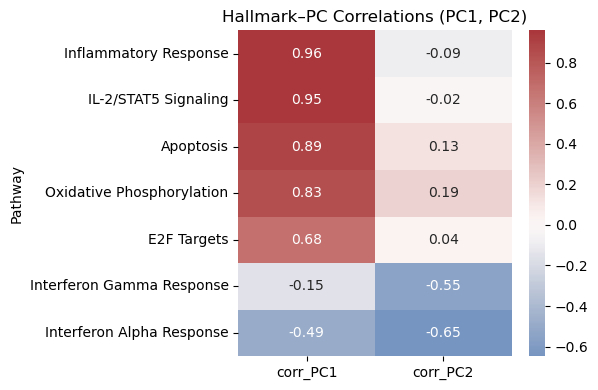

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_df.set_index("Pathway")[["corr_PC1", "corr_PC2"]],
    annot=True, fmt=".2f", center=0, cmap="vlag"
)
plt.title("Hallmark–PC Correlations (PC1, PC2)")
plt.tight_layout()

heatmap_path = PATHWAY_RESULTS_DIR / "hallmark_pc_correlations_PC1_PC2_heatmap.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
heatmap_path


In [177]:
#D. UMAP UMAP outputs → park them in results/umap/
from analysis_utils.config_utils import RESULTS_DIR, ensure_dirs
UMAP_RESULTS_DIR = RESULTS_DIR / "umap"
ensure_dirs(UMAP_RESULTS_DIR)


In [178]:
umap_df.to_csv(UMAP_RESULTS_DIR / "sample_umap_coordinates.csv")


NameError: name 'umap_df' is not defined

In [ ]:
fig_path = UMAP_RESULTS_DIR / "sample_umap_by_hours.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")


In [ ]:
#UMAP
umap_genes_df.to_csv(UMAP_RESULTS_DIR / "gene_umap_with_PCs.csv")

fig_path = UMAP_RESULTS_DIR / "gene_umap_top_PC_quadrant_genes.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

In [1]:
# “Run Everything” cell
def run_full_pca_pipeline():
    # 1. Load inputs
    expr_symbol = pd.read_parquet(PROCESSED_DIR / "expr_logcpm_symbol.parquet")
    metadata    = pd.read_csv(PROCESSED_DIR / "metadata_samples.csv", index_col=0)

    # 2. Run PCA
    scores_df, loadings_df, explained_df, pca = run_pca(
        expr_symbol,
        n_components=20,
        center=True,
        scale=False,
        random_state=0,
    )

    # 3. Save PCA outputs
    save_pca_results(
        scores_df=scores_df,
        loadings_df=loadings_df,
        explained_df=explained_df,
        out_dir=PCA_RESULTS_DIR,
    )

    # 4. Attach PCs to metadata
    meta_pca = metadata.join(scores_df[["PC1", "PC2"]], how="left")

    # 5. Save meta_pca for reuse
    modules_dir = RESULTS_DIR / "modules"
    ensure_dirs(modules_dir)
    meta_pca.to_csv(modules_dir / "metadata_with_PC1_PC2.csv")

    # 6. PCA summary plots
    plot_pca_scatter(
        scores_df=scores_df,
        meta=metadata,
        pc_x="PC5",
        pc_y="PC6",
        color_by="guide",
        out_path=PCA_RESULTS_DIR / "PCA_summary_PC5_PC6_by_guide.png",
    )
    plot_pca_scatter(
        scores_df=scores_df,
        meta=metadata,
        pc_x="PC5",
        pc_y="PC6",
        color_by="hours",
        out_path=PCA_RESULTS_DIR / "PCA_summary_PC5_PC6_by_hours.png",
    )

    # 7. Biological PC1/PC2 interpretive figure
    plot_biological_pca_pc1_pc2(meta_pca)

    return scores_df, loadings_df, explained_df, meta_pca

